<a href="https://colab.research.google.com/github/jashwanthd19/IDRA-Assignments/blob/main/Food_Delivery_Data_Visualization_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (360, 16)

First 5 Rows:
    Order_Batch_ID       Date    Month       Day    City       Cuisine  \
143         FD0144 2025-01-02  January  Thursday  Mumbai       Biryani   
274         FD0275 2025-01-03  January    Friday   Kochi       Chinese   
254         FD0255 2025-01-03  January    Friday   Delhi       Biryani   
35          FD0036 2025-01-04  January  Saturday   Kochi       Chinese   
262         FD0263 2025-01-05  January    Sunday   Kochi  North Indian   

    Order_Channel Weather  Orders  Average_Order_Value   Revenue  \
143       Website   Rainy     153               417.10  60737.12   
274           App     Hot     116               380.72  39270.56   
254       Website   Clear     142               439.59  70923.09   
35            App     Hot     116               360.82  44866.11   
262       Website  Cloudy     117               419.96  48166.96   

     Marketing_Spend  Discounts  Avg_Delivery_Minutes  Customer_Rating  \
143         23547.30    3265.59 

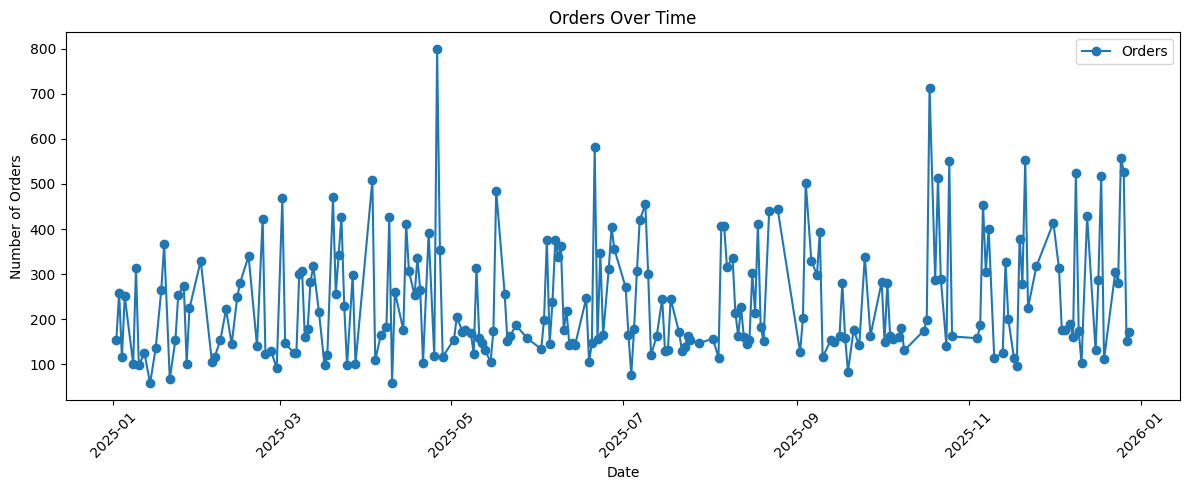

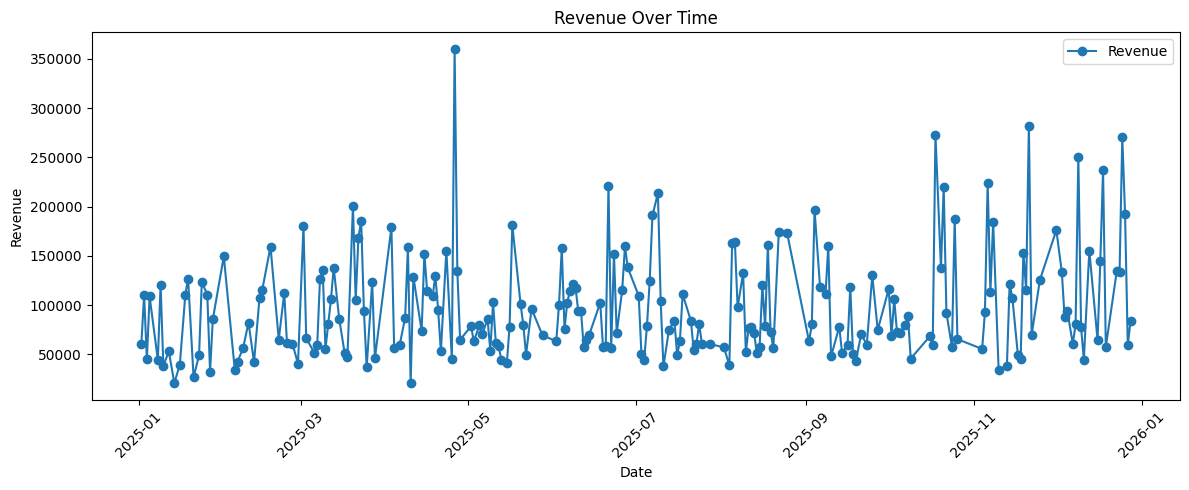

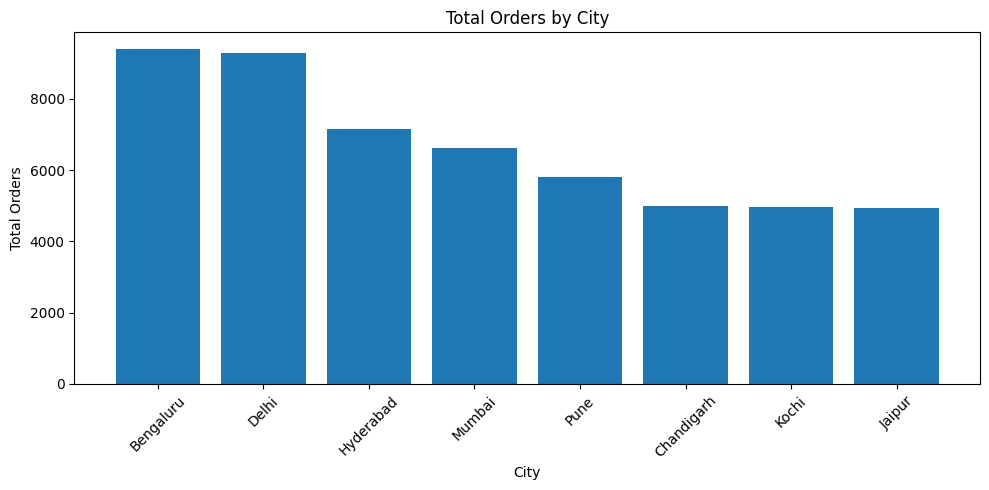

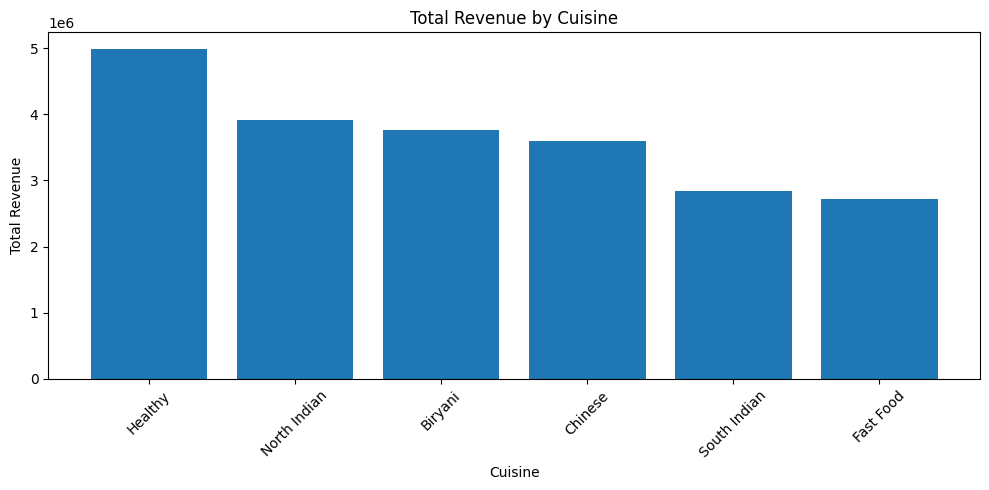

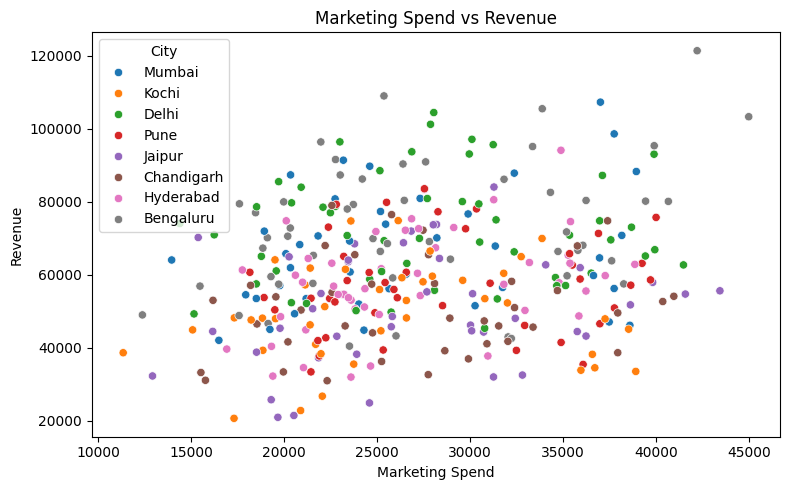

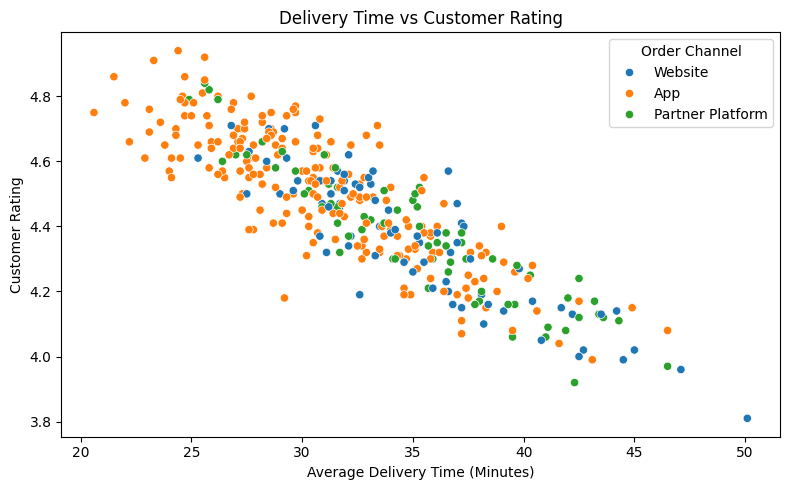

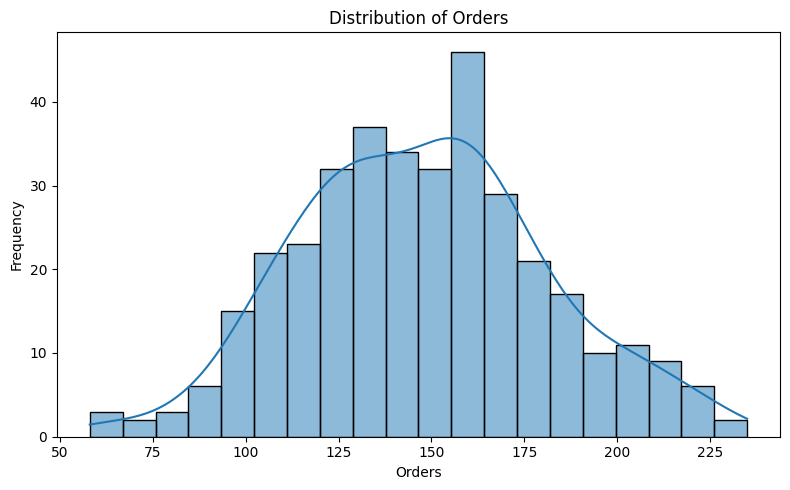

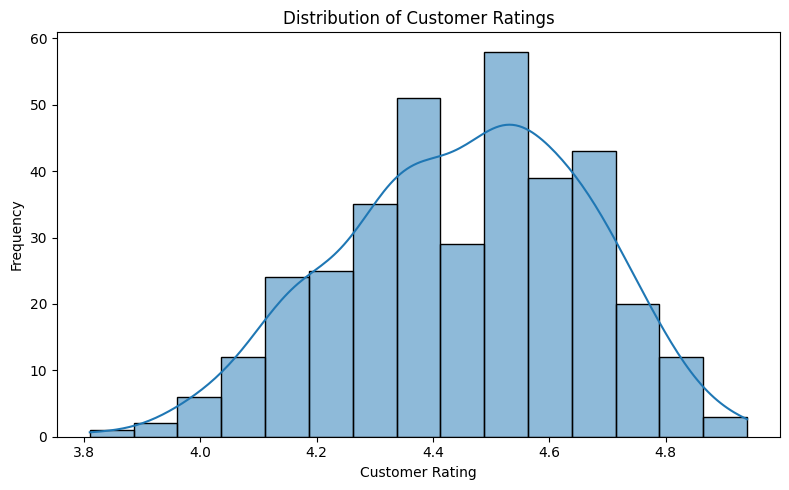

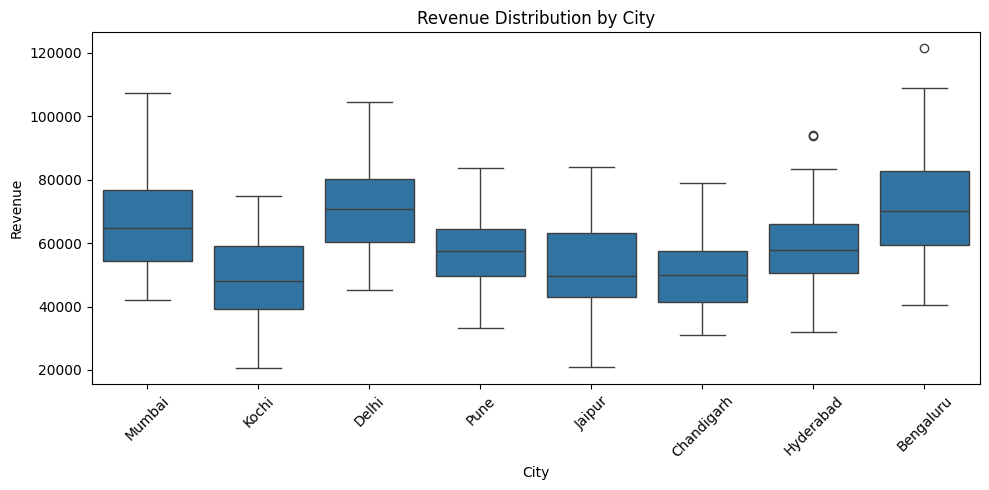

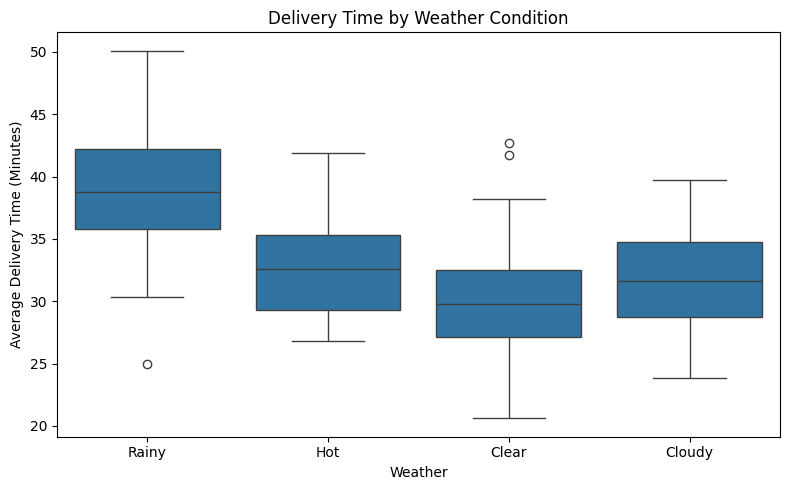

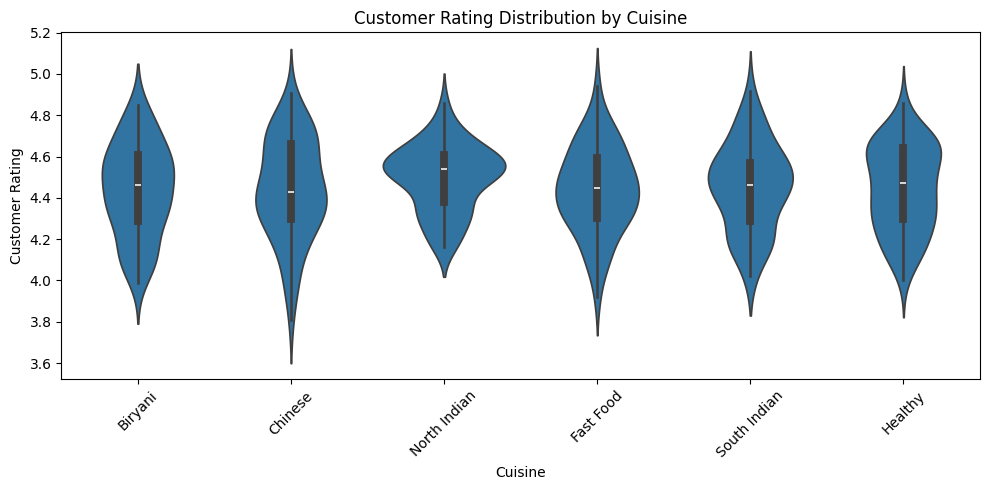

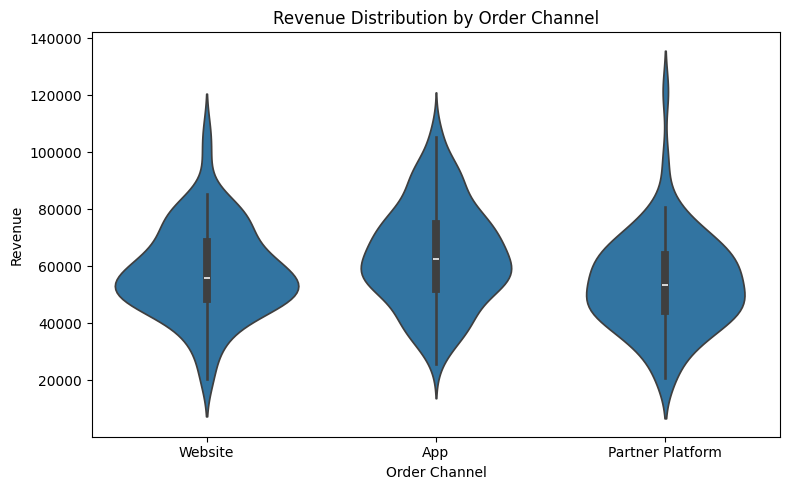

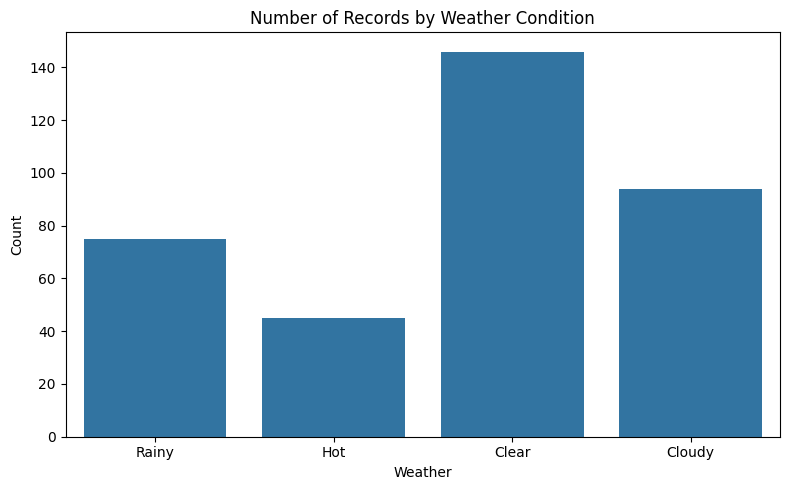

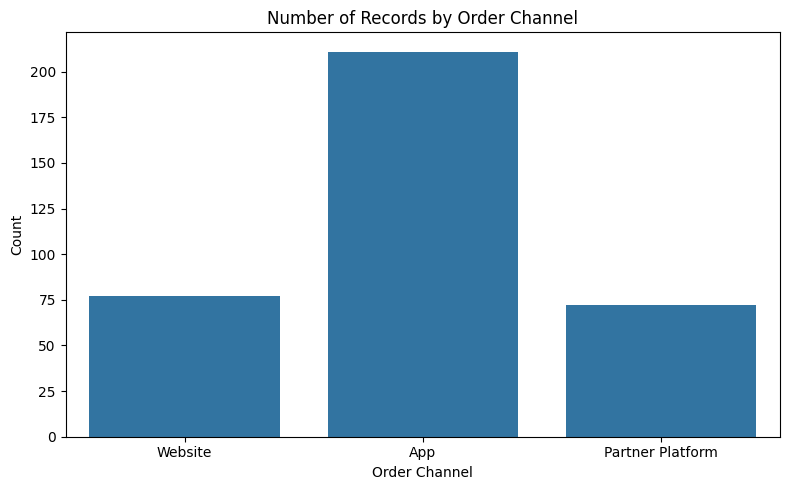

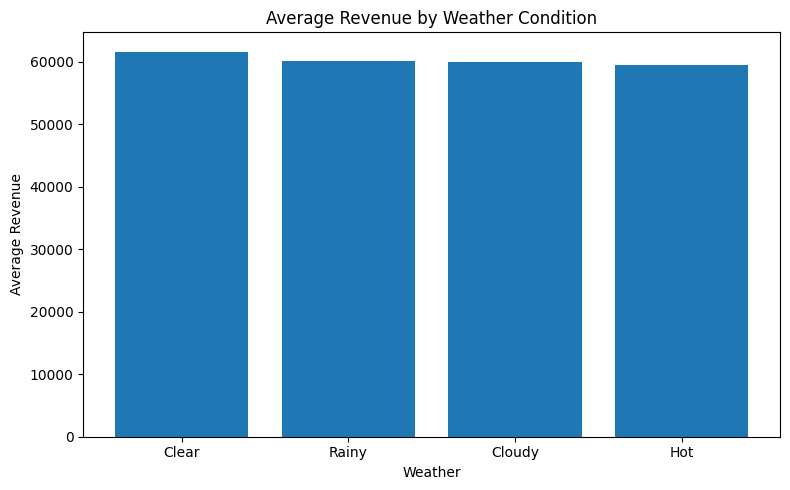

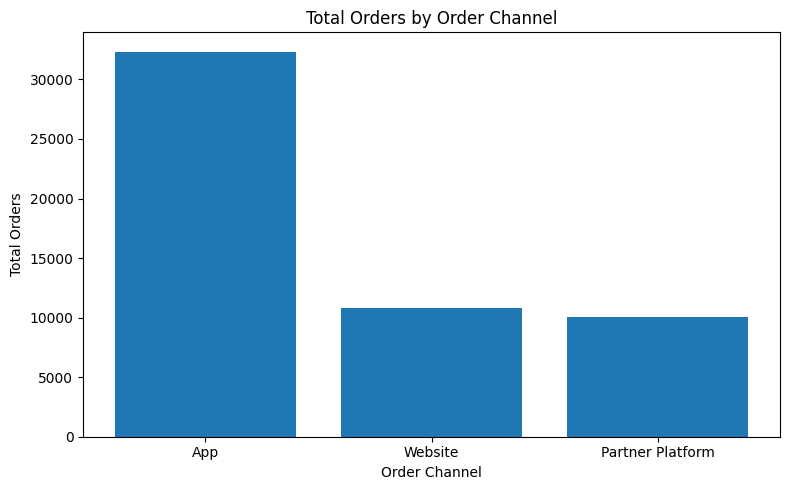


Correlation Matrix:
                         Orders  Average_Order_Value  Revenue  \
Orders                     1.00                -0.01     0.76   
Average_Order_Value       -0.01                 1.00     0.58   
Revenue                    0.76                 0.58     1.00   
Marketing_Spend            0.18                 0.08     0.20   
Discounts                  0.40                 0.30     0.52   
Avg_Delivery_Minutes       0.12                -0.06     0.05   
Customer_Rating           -0.11                 0.02    -0.06   
Repeat_Customer_Percent   -0.00                 0.05     0.03   

                         Marketing_Spend  Discounts  Avg_Delivery_Minutes  \
Orders                              0.18       0.40                  0.12   
Average_Order_Value                 0.08       0.30                 -0.06   
Revenue                             0.20       0.52                  0.05   
Marketing_Spend                     1.00       0.75                 -0.03   
Discount

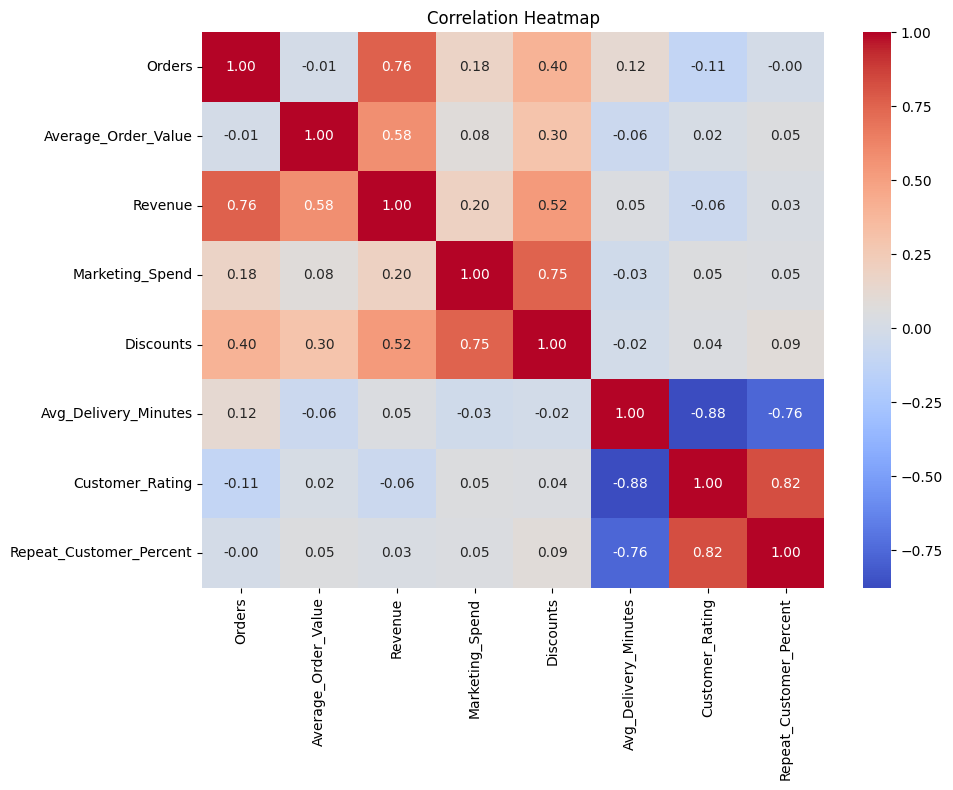


Correlation with Revenue:
Revenue                    1.00
Orders                     0.76
Average_Order_Value        0.58
Discounts                  0.52
Marketing_Spend            0.20
Avg_Delivery_Minutes       0.05
Repeat_Customer_Percent    0.03
Customer_Rating           -0.06
Name: Revenue, dtype: float64

Correlation with Customer Rating:
Customer_Rating            1.00
Repeat_Customer_Percent    0.82
Marketing_Spend            0.05
Discounts                  0.04
Average_Order_Value        0.02
Revenue                   -0.06
Orders                    -0.11
Avg_Delivery_Minutes      -0.88
Name: Customer_Rating, dtype: float64

========== SUMMARY OF FINDINGS ==========
1. City with the highest total orders: Bengaluru with 9394 orders.
2. Cuisine with the highest total revenue: Healthy with revenue of 4988656.66
3. Weather condition with the highest average revenue: Clear with average revenue of 61605.18
4. Order channel with the highest total orders: App with 32335 orders.
5. Va

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("Day14_Food_Delivery_Visualization_Dataset.csv")


df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")


print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


daily_orders = df.groupby("Date")["Orders"].sum()

plt.figure(figsize=(12, 5))
plt.plot(
    daily_orders.index,
    daily_orders.values,
    marker="o",
    label="Orders"
)
plt.title("Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


daily_revenue = df.groupby("Date")["Revenue"].sum()

plt.figure(figsize=(12, 5))
plt.plot(
    daily_revenue.index,
    daily_revenue.values,
    marker="o",
    label="Revenue"
)
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


city_orders = df.groupby("City")["Orders"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 5))
plt.bar(
    city_orders.index,
    city_orders.values
)
plt.title("Total Orders by City")
plt.xlabel("City")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


cuisine_revenue = df.groupby("Cuisine")["Revenue"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 5))
plt.bar(
    cuisine_revenue.index,
    cuisine_revenue.values
)
plt.title("Total Revenue by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue",
    hue="City"
)
plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.legend(title="City")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating",
    hue="Order_Channel"
)
plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Customer Rating")
plt.legend(title="Order Channel")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="Orders",
    bins=20,
    kde=True
)
plt.title("Distribution of Orders")
plt.xlabel("Orders")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="Customer_Rating",
    bins=15,
    kde=True
)
plt.title("Distribution of Customer Ratings")
plt.xlabel("Customer Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="City",
    y="Revenue"
)
plt.title("Revenue Distribution by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Weather",
    y="Avg_Delivery_Minutes"
)
plt.title("Delivery Time by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (Minutes)")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x="Cuisine",
    y="Customer_Rating"
)
plt.title("Customer Rating Distribution by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Customer Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df,
    x="Order_Channel",
    y="Revenue"
)
plt.title("Revenue Distribution by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Weather"
)
plt.title("Number of Records by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Order_Channel"
)
plt.title("Number of Records by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


weather_revenue = df.groupby("Weather")["Revenue"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(8, 5))
plt.bar(
    weather_revenue.index,
    weather_revenue.values
)
plt.title("Average Revenue by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.show()


channel_orders = df.groupby("Order_Channel")["Orders"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(8, 5))
plt.bar(
    channel_orders.index,
    channel_orders.values
)
plt.title("Total Orders by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.show()


numeric_columns = [
    "Orders",
    "Average_Order_Value",
    "Revenue",
    "Marketing_Spend",
    "Discounts",
    "Avg_Delivery_Minutes",
    "Customer_Rating",
    "Repeat_Customer_Percent"
]


correlation_matrix = df[numeric_columns].corr()


print("\nCorrelation Matrix:")
print(correlation_matrix.round(2))


plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


revenue_correlation = correlation_matrix["Revenue"].sort_values(
    ascending=False
)

print("\nCorrelation with Revenue:")
print(revenue_correlation.round(2))


rating_correlation = correlation_matrix["Customer_Rating"].sort_values(
    ascending=False
)

print("\nCorrelation with Customer Rating:")
print(rating_correlation.round(2))


city_revenue = df.groupby("City")["Revenue"].mean().sort_values(
    ascending=False
)

cuisine_rating = df.groupby("Cuisine")["Customer_Rating"].mean().sort_values(
    ascending=False
)


print("\n========== SUMMARY OF FINDINGS ==========")


print(
    "1. City with the highest total orders:",
    city_orders.idxmax(),
    "with",
    city_orders.max(),
    "orders."
)


print(
    "2. Cuisine with the highest total revenue:",
    cuisine_revenue.idxmax(),
    "with revenue of",
    round(cuisine_revenue.max(), 2)
)


print(
    "3. Weather condition with the highest average revenue:",
    weather_revenue.idxmax(),
    "with average revenue of",
    round(weather_revenue.max(), 2)
)


print(
    "4. Order channel with the highest total orders:",
    channel_orders.idxmax(),
    "with",
    channel_orders.max(),
    "orders."
)


print(
    "5. Variable most positively correlated with revenue:",
    revenue_correlation.index[1],
    "with correlation",
    round(revenue_correlation.iloc[1], 2)
)


print(
    "6. Variable most strongly correlated with customer rating:",
    rating_correlation.index[1],
    "with correlation",
    round(rating_correlation.iloc[1], 2)
)


print(
    "7. City with the highest average revenue:",
    city_revenue.idxmax(),
    "with average revenue of",
    round(city_revenue.max(), 2)
)


print(
    "8. Cuisine with the highest average customer rating:",
    cuisine_rating.idxmax(),
    "with average rating of",
    round(cuisine_rating.max(), 2)
)